# MLflow for Darts

This notebook demonstrates how to use Darts with MLflow for experiment tracking, model versioning, and management.
If you are new to Darts, please check out the [Quickstart Guide](https://unit8co.github.io/darts/quickstart/00-quickstart.html) before proceeding.

MLflow is an open-source platform for managing the end-to-end machine learning lifecycle. It provides tools for tracking experiments, packaging code into reproducible runs, sharing and deploying models, and managing model versions in a central registry. With Darts' MLflow integration, you can easily log forecasting models, compare experiments, and manage model versions throughout your forecasting workflow.

For more details, see the [MLflow documentation](https://mlflow.org/docs/latest/index.html).

## Installing MLflow

MLflow is available as an optional dependency for Darts. Install it with:

```bash
pip install mlflow
```

## Setup and Imports

In [2]:
# fix python path if working locally
from utils import fix_pythonpath_if_working_locally

fix_pythonpath_if_working_locally()

import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

In [3]:
%matplotlib inline

import os
import tempfile

import matplotlib.pyplot as plt
import mlflow
import numpy as np

import darts.metrics
from darts.datasets import AirPassengersDataset
from darts.models import ExponentialSmoothing, LinearRegressionModel, NBEATSModel
from darts.utils.mlflow import autolog, load_model, log_model, save_model

In [4]:
# use darts plotting style
from darts import set_option

set_option("plotting.use_darts_style", True)

## MLflow Setup

First, let's configure MLflow tracking. We'll use a temporary directory for this example, however you can choose from any of the supported MLflow [tracking backends](https://mlflow.org/docs/latest/self-hosting/architecture/tracking-server/#backend-store) such as local filesystem, SQLite, PostgreSQL, MySQL, or cloud storage solutions like S3 or Azure Blob Storage.

In [5]:
# temporary directory for MLflow tracking
tmpdir = tempfile.mkdtemp()
mlflow_db = os.path.join(tmpdir, "mlflow.db")

mlflow.set_tracking_uri(f"sqlite:///{mlflow_db}")
mlflow.set_experiment("darts-quickstart")

print(f"MLflow tracking URI: {mlflow.get_tracking_uri()}")
print(f"Experiment: {mlflow.get_experiment_by_name('darts-quickstart').name}")

2026/06/25 13:57:21 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/25 13:57:21 INFO mlflow.store.db.utils: Updating database tables
2026/06/25 13:57:22 INFO mlflow.tracking.fluent: Experiment with name 'darts-quickstart' does not exist. Creating a new experiment.


MLflow tracking URI: sqlite:////var/folders/yr/3703qwtj56lcw6n91xm6tq_r0000gn/T/tmpvwnlx3yj/mlflow.db
Experiment: darts-quickstart


## Load Sample Data

We'll use the classic AirPassengers dataset for this example.

findfont: Failed to find font weight 600, now using 700.


Training series: 107 points
Validation series: 37 points


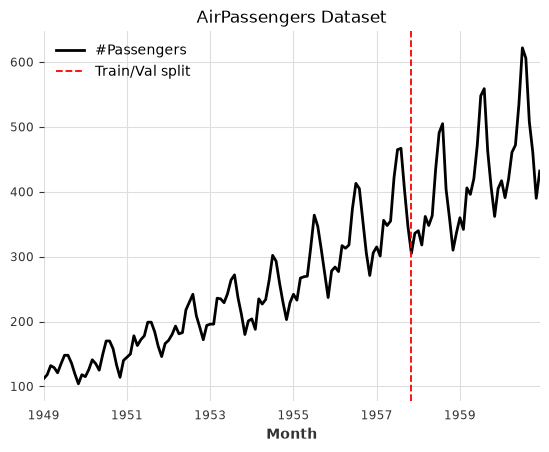

In [6]:
series = AirPassengersDataset().load()
train, val = series.split_before(0.75)

print(f"Training series: {len(train)} points")
print(f"Validation series: {len(val)} points")

series.plot()
plt.axvline(train.end_time(), color="red", linestyle="--", label="Train/Val split")
plt.legend()
plt.title("AirPassengers Dataset")
plt.show()

## Basic Model Logging

Let's train a simple model and log it to MLflow manually.

Validation MAPE: 7.86%
Validation RMSE: 34.77


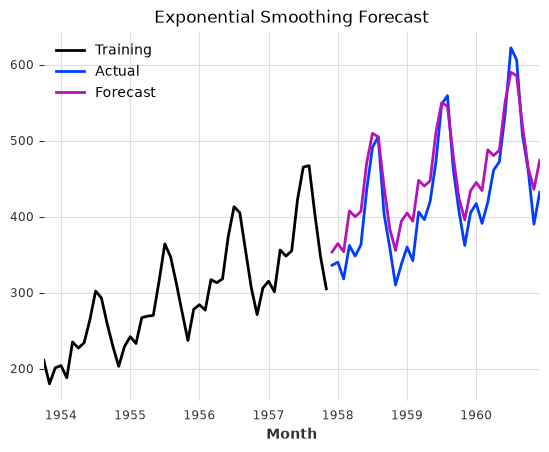

In [7]:
model = ExponentialSmoothing()
model.fit(train)

predictions = model.predict(n=len(val))

# calculate metrics you want to log to MLflow
mape_score = darts.metrics.mape(val, predictions)
rmse_score = darts.metrics.rmse(val, predictions)

print(f"Validation MAPE: {mape_score:.2f}%")
print(f"Validation RMSE: {rmse_score:.2f}")

train[-50:].plot(label="Training")
val.plot(label="Actual")
predictions.plot(label="Forecast")
plt.legend()
plt.title("Exponential Smoothing Forecast")
plt.show()

Now let's log this model to MLflow:

In [8]:
with mlflow.start_run(run_name="exponential-smoothing-baseline") as run:
    model_info = log_model(
        model=model,
        name="exponential-smoothing-model",
        # alternatively, use mlflow.set_tag(key, value) in the run
        tags={"model_type": "ExponentialSmoothing", "dataset": "AirPassengers"},
    )

    # log calculated metrics you want
    mlflow.log_metric("val_mape", mape_score)
    mlflow.log_metric("val_rmse", rmse_score)

    print(f"Run ID: {run.info.run_id}")
    print(f"Model URI: {model_info.model_uri}")

2026/06/25 13:57:23 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Run ID: 22b3b299ce8d4d72b1646564a35b04ee
Model URI: models:/m-e61e8518e2a04143ace1d627ed4a775b


### Load the Model Back

We can load the model from MLflow using its URI:

In [9]:
loaded_model = load_model(model_info.model_uri)

loaded_predictions = loaded_model.predict(n=len(val))

# verify predictions match
predictions_match = np.allclose(predictions.values(), loaded_predictions.values())
print(f"Loaded model predictions match: {predictions_match}")

Loaded model predictions match: True


## Automatic Logging with `autolog()`

`autolog()` patches every `model.fit()` call to automatically log parameters, covariate metadata, and the trained model artifact. It also patches the darts metric functions so any metric called inside an active run is logged. For PyTorch-based models it enables MLflow's PyTorch autologging to record `train_loss` / `val_loss` per epoch (see the sections below for details).

2026/06/25 13:57:26 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/06/25 13:57:26 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Logged metrics: {'val_mape': 10.742, 'val_rmse': 51.182}


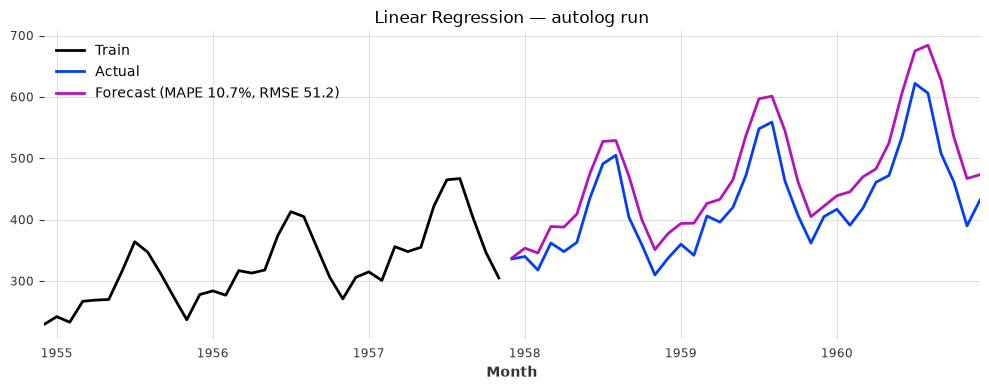

In [10]:
autolog()

with mlflow.start_run(run_name="linear-regression-autolog") as run:
    auto_model = LinearRegressionModel(lags=12)
    auto_model.fit(train)  # autolog logs params, covariate metadata, and the model

    auto_predictions = auto_model.predict(n=len(val))
    # these metric calls happen inside the run, so they are logged automatically
    auto_mape = darts.metrics.mape(val, auto_predictions)
    auto_rmse = darts.metrics.rmse(val, auto_predictions)

autolog(disable=True)

# show logged metrics
logged = mlflow.tracking.MlflowClient().get_run(run.info.run_id).data.metrics
print("Logged metrics:", {k: round(v, 4) for k, v in sorted(logged.items())})

# plot
fig, ax = plt.subplots(figsize=(10, 4))
train[-36:].plot(label="Train", ax=ax)
val.plot(label="Actual", ax=ax)
auto_predictions.plot(
    label=f"Forecast (MAPE {auto_mape:.1f}%, RMSE {auto_rmse:.1f})", ax=ax
)
ax.set_title("Linear Regression — autolog run")
ax.legend()
plt.tight_layout()
plt.show()

## Open the MLflow UI

To experiment with the runs yourself, open the **MLflow UI** to explore them interactively. Run the command printed below in a separate terminal, then navigate to `http://localhost:5000`.

The UI lets you:
- **Compare runs** side-by-side in the Experiments table
- **Inspect** individual run parameters, metrics, and logged artifacts
- **Visualize** metrics across runs with built-in charts
- **Register** models to the Model Registry for versioning

In [11]:
print("Launch the MLflow UI with this command in your terminal:\n")
print(f"  mlflow ui --backend-store-uri {mlflow.get_tracking_uri()}\n")
print("Then open:  http://localhost:5000")

Launch the MLflow UI with this command in your terminal:

  mlflow ui --backend-store-uri sqlite:////var/folders/yr/3703qwtj56lcw6n91xm6tq_r0000gn/T/tmpvwnlx3yj/mlflow.db

Then open:  http://localhost:5000


> 📸 **Try it:** Open the UI, switch to the `darts-quickstart` experiment, and sort the **Table view** by `val_mape` to instantly see which model performs best. Click any run name to see its parameters, tags, and logged artifacts.
>
![Mlflow Overview](./static/images/mlflow_overview.png)

## Per-epoch Metrics with Torch Models

For neural models, `autolog()` enables MLflow's PyTorch autologging, which records `train_loss` and `val_loss` at the end of every epoch.

Pass `torch_metrics` to the model to add extra per-epoch metrics (e.g. MAE, MSE). They will appear prefixed as `train_MAE`, `val_MAE`, etc.

In [12]:
from torchmetrics import MeanAbsoluteError, MeanSquaredError, MetricCollection

# per-epoch train_loss / val_loss are logged via MLflow's PyTorch autologging
autolog()

with mlflow.start_run(run_name="nbeats-epoch-metrics"):
    nbeats = NBEATSModel(
        input_chunk_length=24,
        output_chunk_length=12,
        n_epochs=10,
        pl_trainer_kwargs={"accelerator": "cpu"},
        # these are logged per epoch as train_MAE, val_MAE, train_MSE, val_MSE
        torch_metrics=MetricCollection({
            "MAE": MeanAbsoluteError(),
            "MSE": MeanSquaredError(),
        }),
        random_state=42,
    )
    nbeats.fit(train, val_series=val)
    nbeats_pred = nbeats.predict(n=len(val))
    # metric calls inside the run are logged automatically (keys: val_mape, val_rmse)
    nbeats_mape = darts.metrics.mape(val, nbeats_pred)
    nbeats_rmse = darts.metrics.rmse(val, nbeats_pred)
    print(f"NBEATS MAPE: {nbeats_mape:.2f}%")
    print(f"NBEATS RMSE: {nbeats_rmse:.2f}")

autolog(disable=True)

INFO: GPU available: True (mps), used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (mps), used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | stacks          | ModuleList       | 6.2 M  | train
-------------------------------------------------------------
6.2 M     Trainable params
1.4 K     Non-trainable params
6.2 M     Total params
24.787    Total estimat

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/Users/jakubchlapek/Desktop/projects/darts/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/jakubchlapek/Desktop/projects/darts/.venv/lib/python3.11/site-packages/pytorch_lightning/core/module.py:512: You called `self.log('val_MAE', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`
/Users/jakubchlapek/Desktop/projects/darts/.venv/lib/python3.11/site-packages/pytorch_lightning/core/module.py:512: You called `self.log('val_MSE', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=10` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.
2026/06/25 13:57:29 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
INFO: GPU available: True (mps), used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (mps), used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

NBEATS MAPE: 13.64%
NBEATS RMSE: 63.33


> 📸 **Try it:** Click on the `nbeats-epoch-metrics` run in the UI, then open the **Model metrics** tab. You'll see `train_loss`, `val_loss`, `train_MAE`, and `val_MAE` plotted as learning curves across epochs.
>
![Mlflow Charts](./static/images/mlflow_charts.png)

## Forecast Metrics

With `log_metrics=True` (the default), `autolog()` patches every darts metric function. Any metric you call **inside an active run** is logged automatically with no extra arguments needed.

The metric key is derived from the result: a scalar is logged under `{metric}`, and when the variable name of the actual series can be detected it is prefixed (e.g. calling `darts.metrics.mae(val, pred)` logs `val_mae`). You can always log a custom-named metric explicitly with `mlflow.log_metric()`.

In [13]:
# log_metrics=True (the default) patches every darts metric so that calls made
# inside an active run are logged automatically
autolog(log_metrics=True)

with mlflow.start_run(run_name="linear-regression-full-metrics") as run:
    lr_model = LinearRegressionModel(lags=12)
    lr_model.fit(train)
    lr_pred = lr_model.predict(n=len(val))

    # each metric called here is auto-logged; the key is prefixed with the
    # variable name of the first argument (here "val"): val_mae, val_rmse, val_smape
    darts.metrics.mae(val, lr_pred)
    darts.metrics.rmse(val, lr_pred)
    darts.metrics.smape(val, lr_pred)
    # you can still log a custom-named metric explicitly
    mlflow.log_metric("manual_mape", darts.metrics.mape(val, lr_pred))
    run_id = run.info.run_id

autolog(disable=True)

# show what was logged
client = mlflow.tracking.MlflowClient()
run_metrics = client.get_run(run_id).data.metrics
metric_names = sorted(run_metrics.keys())
print(f"All logged metrics ({len(metric_names)}):")
for name in metric_names:
    print(f"  {name}: {run_metrics[name]:.4f}")

2026/06/25 13:57:29 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/06/25 13:57:29 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


All logged metrics (5):
  manual_mape: 10.7420
  val_mae: 46.0220
  val_mape: 10.7420
  val_rmse: 51.1820
  val_smape: 10.1015


### Metric Shape and Per-Series Logging

The logged key reflects the shape of the metric output, which `autolog()` infers from the metric and its keyword arguments. The general pattern is:

`{dataset_name}_{metric_name}{component}{quantile_or_label}`

Per-component results (`component_reduction=None`) add the component name (e.g. `val_mae_<component>`), quantile metrics (`q`, `q_interval`) add the quantile (e.g. `val_mql_q0.5`), per-label classification (`label_reduction=None`) adds the class (e.g. `val_f1_label1`), and per-timestep metrics (`time_reduction=None`) are charted across MLflow steps.

When you score a list of series, the logged value is the mean over series and the full per-series breakdown is saved as a CSV artifact under `per_series_metrics/`.

In [14]:
import csv

import darts.metrics as dm

# build a small multi-series example from the univariate AirPassengers data
series_list = [train, train * 1.2]
val_list = [val, val * 1.2]

multi_model = LinearRegressionModel(lags=12)
multi_model.fit(series_list)
multi_preds = multi_model.predict(n=len(val), series=series_list)

autolog(log_metrics=True)

with mlflow.start_run(run_name="metric-shape-and-csv") as run:
    # metric shape: a per-timestep metric (ae) logs one value per horizon step
    # under a single key, charted across MLflow steps
    single_pred = multi_model.predict(n=len(val), series=train)
    dm.ae(val, single_pred)

    # multiple series: the logged value is the MEAN over series, and the full
    # per-series breakdown is written to a CSV artifact
    per_series_mae = dm.mae(val_list, multi_preds)

autolog(disable=True)

client = mlflow.tracking.MlflowClient()
run_id = run.info.run_id

# aggregate metrics: val_list_mae is the mean over the two series
logged = client.get_run(run_id).data.metrics
print("Aggregate metrics:", {k: round(v, 3) for k, v in sorted(logged.items())})
print("Mean MAE over series:", round(float(np.mean(per_series_mae)), 3))

# download and inspect the per-series CSV artifact
csv_path = mlflow.artifacts.download_artifacts(
    run_id=run_id, artifact_path="per_series_metrics/val_list_mae_per_series.csv"
)
with open(csv_path) as f:
    rows = list(csv.DictReader(f))

print("\nPer-series breakdown (val_list_mae_per_series.csv):")
for row in rows:
    print(f"  series {row['series_index']}: {row['key']} = {float(row['value']):.3f}")

Aggregate metrics: {'val_ae': 44.196, 'val_list_mae': 51.316}
Mean MAE over series: 51.316



Per-series breakdown (val_list_mae_per_series.csv):
  series 0: val_list_mae = 47.459
  series 1: val_list_mae = 55.173


## Saving and Loading Models Locally

You can also save and load models to/from local paths without MLflow runs.

In [15]:
# Save model to local directory
local_model_path = os.path.join(tmpdir, "my_model")
save_model(model, path=local_model_path)

print("\nFiles in model directory:")
for file in os.listdir(local_model_path):
    print(f"  - {file}")

2026/06/25 13:57:29 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



Files in model directory:
  - python_env.yaml
  - requirements.txt
  - MLmodel
  - model.pkl
  - conda.yaml


In [16]:
# Load model from local directory
local_loaded_model = load_model(f"file://{local_model_path}")

# Test it
local_predictions = local_loaded_model.predict(n=5)
print("Loaded model successfully!")
print(f"Predictions shape: {local_predictions.values().shape}")

Loaded model successfully!
Predictions shape: (5, 1)


## Querying Experiments

You can programmatically query and compare runs.

In [17]:
from mlflow.tracking import MlflowClient

experiment = mlflow.get_experiment_by_name("darts-quickstart")

# get all runs
client = MlflowClient()
runs = client.search_runs(
    experiment_ids=[experiment.experiment_id],
    order_by=["metrics.val_mape ASC"],  # Sort by best MAPE
)

print(f"Found {len(runs)} runs in experiment '{experiment.name}':\n")
for i, run in enumerate(runs, 1):
    run_name = run.data.tags.get("mlflow.runName", "Unnamed")
    mape_val = run.data.metrics.get("val_mape", "N/A")
    print(f"{i}. {run_name}")
    print(f"   Run ID: {run.info.run_id}")
    print(f"   Validation MAPE: {mape_val}")
    print()

Found 5 runs in experiment 'darts-quickstart':

1. exponential-smoothing-baseline
   Run ID: 22b3b299ce8d4d72b1646564a35b04ee
   Validation MAPE: 7.864181481214469

2. linear-regression-full-metrics
   Run ID: 91ea26f4a5d448269c704a772c53f695
   Validation MAPE: 10.742044444678953

3. linear-regression-autolog
   Run ID: eed13fa115304f6e853dfd4bf755211c
   Validation MAPE: 10.742044444678953

4. nbeats-epoch-metrics
   Run ID: a1acc6779c7b4f158ac95f26bb108b74
   Validation MAPE: 13.639569217869525

5. metric-shape-and-csv
   Run ID: 13a91160d03f414892139f7831ba509d
   Validation MAPE: N/A



### Load the Best Model

Loading best model from run: exponential-smoothing-baseline
Model URI: models:/m-e61e8518e2a04143ace1d627ed4a775b


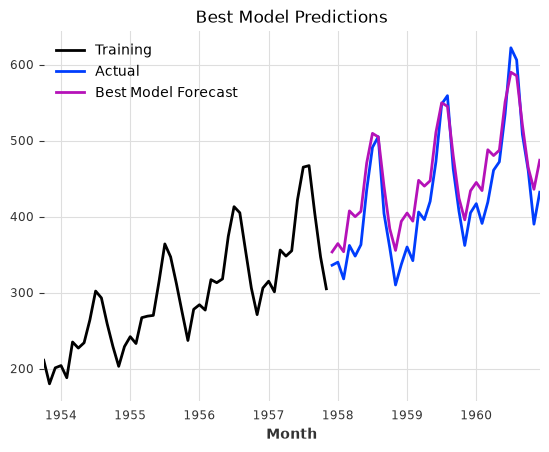

In [18]:
from darts.models.forecasting.forecasting_model import GlobalForecastingModel

if runs:
    best_run = runs[0]
    # the model is logged via MLflow's logged-model API, so resolve its model_id
    # from the run outputs and load it with a models:/ URI
    model_outputs = mlflow.get_run(best_run.info.run_id).outputs.model_outputs
    best_model_uri = f"models:/{model_outputs[0].model_id}"

    print(f"Loading best model from run: {best_run.data.tags.get('mlflow.runName')}")
    print(f"Model URI: {best_model_uri}")

    best_model = load_model(best_model_uri)
    # global models (e.g. LinearRegression, NBEATS) need the series at predict time
    # because we save with clean=True; local models (e.g. ExponentialSmoothing) don't
    if isinstance(best_model, GlobalForecastingModel):
        best_predictions = best_model.predict(n=len(val), series=train)
    else:
        best_predictions = best_model.predict(n=len(val))

    train[-50:].plot(label="Training")
    val.plot(label="Actual")
    best_predictions.plot(label="Best Model Forecast")
    plt.legend()
    plt.title("Best Model Predictions")
    plt.show()

## Model Registry

After comparing runs in the UI you can promote your best model to the **MLflow Model Registry** for versioning and lifecycle management (Staging → Production → Archived).

```python
# Register a model from a run
result = mlflow.register_model(
    model_uri=f"runs:/{best_run.info.run_id}/model",
    name="darts-air-passengers",
)
print(f"Registered version: {result.version}")
```

The registry is accessible in the MLflow UI under the **Models** tab, where you can add descriptions, set aliases, and compare versions side-by-side.

> 📸 **Try it:** After running the cells above, open the Models tab in the UI and register one of the runs.
>
![Mlflow Charts](./static/images/mlflow_models.png)

## Important Note: Custom Flavor

Since Darts uses a custom MLflow flavor on its' side it's important to import the methods accordingly.

**Always use:**
```python
from darts.utils.mlflow import load_model
model = load_model(model_uri)
```

**Instead of:**
```python
import mlflow
model = mlflow.pyfunc.load_model(model_uri)  # Will fail!
```

This custom flavor is necessary to properly handle:
- TimeSeries objects
- Darts-specific model parameters
- Covariate handling (past, future, static)
- PyTorch model state preservation

## Cleanup

In [19]:
# Uncomment to cleanup
# import shutil
# shutil.rmtree(tmpdir)
# print(f"Cleaned up temporary directory: {tmpdir}")

print(f"To cleanup manually, delete: {tmpdir}")

To cleanup manually, delete: /var/folders/yr/3703qwtj56lcw6n91xm6tq_r0000gn/T/tmpvwnlx3yj


# Final Remarks

Currently none of the model serving capabilities are implemented for Darts. While an API was provided (`input_example` and `signature` parameters for the `.log_model` and `.load_model`) to keep in line with MLflow API conventions, they are currently widely unsupported.